## Problem 1: Binomial Distribution - Pet Ownership

**Problem Statement:**
Out of 800 families with 4 pets (dog or cat) each, how many families would be expected to have:
- (i) 2 dogs and 2 cats
- (ii) at least 1 dog
- (iii) at most 2 cats
- (iv) both dog and cat

**Solution:**
Assuming equal probability of dog or cat for each pet (p = 0.5)
- Total families = 800
- Each family has 4 pets
- Number of dogs follows Binomial(n=4, p=0.5)


PROBLEM 1: Binomial Distribution - Pet Ownership
Total Families: 800
Pets per family: 4
Probability of dog: 0.5, Probability of cat: 0.5

(i) Families with 2 dogs and 2 cats:
    P(X = 2) = C(4,2) × (0.5)^2 × (0.5)^2 = 0.375000
    Expected families = 300.0

(ii) Families with at least 1 dog:
    P(X ≥ 1) = 1 - P(X = 0) = 0.937500
    Expected families = 750.0

(iii) Families with at most 2 cats (≥ 2 dogs):
    P(X ≥ 2) = 1 - [P(X=0) + P(X=1)] = 0.687500
    Expected families = 550.0

(iv) Families with both dog and cat:
    P(1 ≤ X ≤ 3) = P(X≤3) - P(X=0) = 0.875000
    Expected families = 700.0


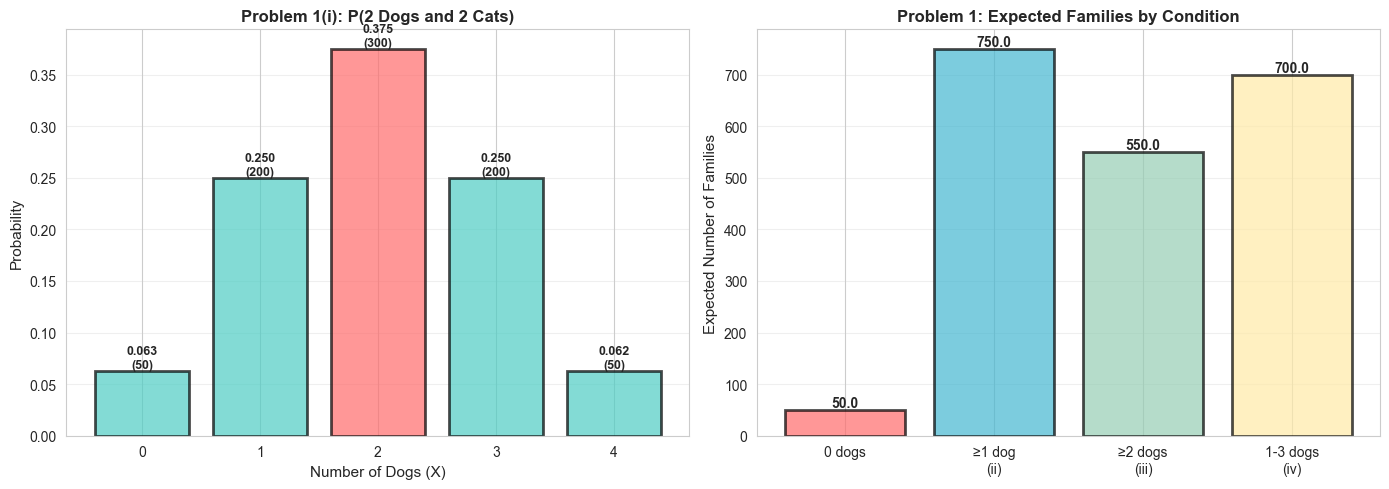

In [6]:
# Problem 1: Binomial Distribution - Pet Ownership
from math import comb

total_families = 800
n_pets = 4  # Each family has 4 pets
p = 0.5  # Equal probability of dog or cat
q = 0.5  # Probability of the other

# Create Binomial distribution
binom_dist = stats.binom(n=n_pets, p=p)

# (i) P(2 dogs and 2 cats) = P(X = 2) where X is number of dogs
prob_1_i = binom_dist.pmf(2)
families_1_i = prob_1_i * total_families

# (ii) P(at least 1 dog) = 1 - P(X = 0)
prob_1_ii = 1 - binom_dist.pmf(0)
families_1_ii = prob_1_ii * total_families

# (iii) P(at most 2 cats) = P(at least 2 dogs) = P(X >= 2) = 1 - P(X < 2) = 1 - P(X=0) - P(X=1)
prob_at_least_2_dogs = 1 - binom_dist.cdf(1)
families_1_iii = prob_at_least_2_dogs * total_families

# (iv) P(both dog and cat) = P(at least 1 dog AND at least 1 cat) = P(1 <= X <= 3)
prob_1_iv = binom_dist.cdf(3) - binom_dist.cdf(0)
families_1_iv = prob_1_iv * total_families

print("\n" + "=" * 70)
print("PROBLEM 1: Binomial Distribution - Pet Ownership")
print("=" * 70)
print(f"Total Families: {total_families}")
print(f"Pets per family: {n_pets}")
print(f"Probability of dog: {p}, Probability of cat: {q}")
print("\n(i) Families with 2 dogs and 2 cats:")
print(f"    P(X = 2) = C(4,2) × (0.5)^2 × (0.5)^2 = {prob_1_i:.6f}")
print(f"    Expected families = {families_1_i:.1f}")

print("\n(ii) Families with at least 1 dog:")
print(f"    P(X ≥ 1) = 1 - P(X = 0) = {prob_1_ii:.6f}")
print(f"    Expected families = {families_1_ii:.1f}")

print("\n(iii) Families with at most 2 cats (≥ 2 dogs):")
print(f"    P(X ≥ 2) = 1 - [P(X=0) + P(X=1)] = {prob_at_least_2_dogs:.6f}")
print(f"    Expected families = {families_1_iii:.1f}")

print("\n(iv) Families with both dog and cat:")
print(f"    P(1 ≤ X ≤ 3) = P(X≤3) - P(X=0) = {prob_1_iv:.6f}")
print(f"    Expected families = {families_1_iv:.1f}")
print("=" * 70)

# Visualization
x_vals = np.arange(0, 5)
pmf = binom_dist.pmf(x_vals)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
colors = ['#FF6B6B' if i == 2 else '#4ECDC4' for i in x_vals]
bars = plt.bar(x_vals, pmf, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.xlabel('Number of Dogs (X)', fontsize=11)
plt.ylabel('Probability', fontsize=11)
plt.title('Problem 1(i): P(2 Dogs and 2 Cats)', fontsize=12, fontweight='bold')
plt.xticks(x_vals)
for i, (x, p_val) in enumerate(zip(x_vals, pmf)):
    plt.text(x, p_val, f'{p_val:.3f}\n({p_val*total_families:.0f})', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
bar_labels = ['X=0\n(all cats)', 'X=1\n(1 dog)', 'X=2\n(2 dogs)', 'X=3\n(3 dogs)', 'X=4\n(all dogs)']
scenarios = ['0 dogs', '≥1 dog\n(ii)', '≥2 dogs\n(iii)', '1-3 dogs\n(iv)']
probs = [binom_dist.pmf(0), prob_1_ii, prob_at_least_2_dogs, prob_1_iv]
families = [p*total_families for p in probs]
colors_bar = ['#FF6B6B', '#45B7D1', '#96CEB4', '#FFEAA7']

bars = plt.bar(scenarios, families, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Expected Number of Families', fontsize=11)
plt.title('Problem 1: Expected Families by Condition', fontsize=12, fontweight='bold')
for bar, fam in zip(bars, families):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{fam:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Problem 3: Hypergeometric Distribution - Taxi Cabs

**Problem Statement:**
A taxi cab company has 12 Ambassadors and 8 Fiats. If 5 of these taxi cabs are in workshop for repairs and an Ambassador is as likely to be in for repairs as a Fiat, what is the probability that:
- (i) 3 of them are Ambassadors and 2 are Fiats
- (ii) at least 3 of them are Ambassadors
- (iii) all the 5 are of the same make

**Solution:**
Hypergeometric distribution:
- Population size: N = 20 (12 Ambassadors + 8 Fiats)
- Number of success states in population: K = 12 Ambassadors
- Number of draws: n = 5 taxis in repair


PROBLEM 3: Hypergeometric Distribution - Taxi Cabs
Total Taxis: 20
Ambassadors: 12, Fiats: 8
Taxis in workshop: 5

(i) P(3 Ambassadors and 2 Fiats):
    P(X = 3) = C(12,3) × C(8,2) / C(20,5)
             = 220 × 28 / 15504
             = 0.397317

(ii) P(at least 3 Ambassadors):
    P(X ≥ 3) = P(X=3) + P(X=4) + P(X=5)
             = 0.397317 + 0.255418 + 0.051084
             = 0.703818

(iii) P(all 5 are of same make):
    P(X=5) + P(X=0) = (all Ambassadors) + (all Fiats)
                    = 0.051084 + 0.003612
                    = 0.054696


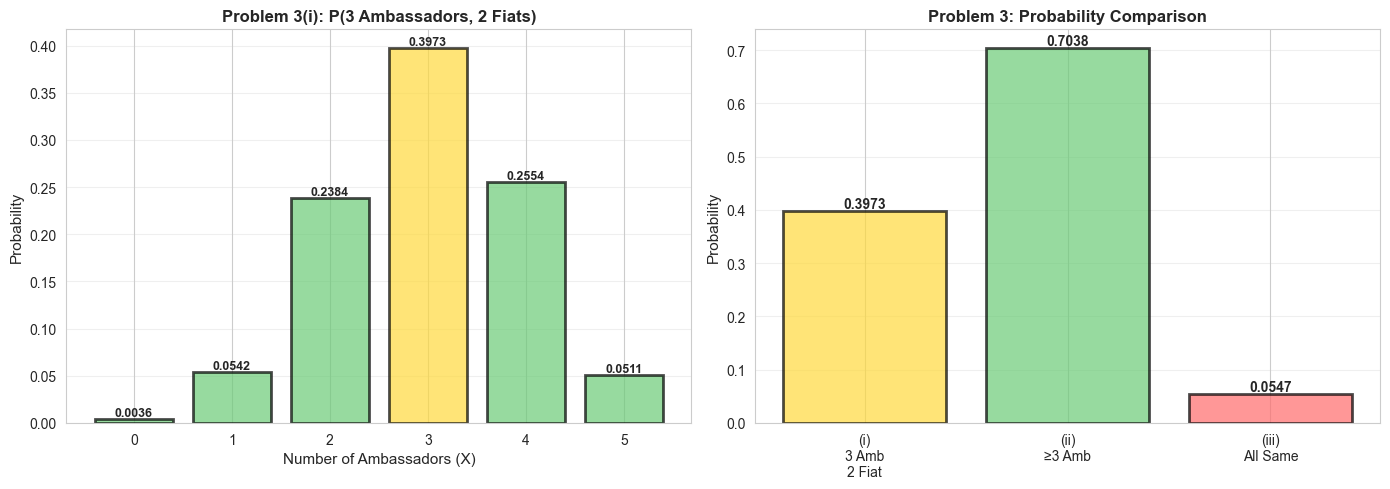

In [7]:
# Problem 3: Hypergeometric Distribution - Taxi Cabs
# Parameters
N = 20  # Total taxis (12 Ambassadors + 8 Fiats)
K = 12  # Number of Ambassadors
n_draw = 5  # Taxis in workshop

# Create Hypergeometric distribution
hypergeo_dist = stats.hypergeom(M=N, n=K, N=n_draw)

# (i) P(X = 3) - exactly 3 Ambassadors and 2 Fiats
prob_3_i = hypergeo_dist.pmf(3)

# (ii) P(X >= 3) - at least 3 Ambassadors
prob_3_ii = 1 - hypergeo_dist.cdf(2)

# (iii) All 5 are of same make: P(X=5) or P(X=0)
prob_5_ambassadors = hypergeo_dist.pmf(5)
prob_0_ambassadors = hypergeo_dist.pmf(0)  # All Fiats
prob_3_iii = prob_5_ambassadors + prob_0_ambassadors

print("\n" + "=" * 70)
print("PROBLEM 3: Hypergeometric Distribution - Taxi Cabs")
print("=" * 70)
print(f"Total Taxis: {N}")
print(f"Ambassadors: {K}, Fiats: {N-K}")
print(f"Taxis in workshop: {n_draw}")
print(f"\n(i) P(3 Ambassadors and 2 Fiats):")
print(f"    P(X = 3) = C(12,3) × C(8,2) / C(20,5)")
print(f"             = {comb(12,3)} × {comb(8,2)} / {comb(20,5)}")
print(f"             = {prob_3_i:.6f}")

print(f"\n(ii) P(at least 3 Ambassadors):")
print(f"    P(X ≥ 3) = P(X=3) + P(X=4) + P(X=5)")
print(f"             = {hypergeo_dist.pmf(3):.6f} + {hypergeo_dist.pmf(4):.6f} + {hypergeo_dist.pmf(5):.6f}")
print(f"             = {prob_3_ii:.6f}")

print(f"\n(iii) P(all 5 are of same make):")
print(f"    P(X=5) + P(X=0) = (all Ambassadors) + (all Fiats)")
print(f"                    = {prob_5_ambassadors:.6f} + {prob_0_ambassadors:.6f}")
print(f"                    = {prob_3_iii:.6f}")
print("=" * 70)

# Visualization
x_vals_hyp = np.arange(0, 6)
pmf_hyp = hypergeo_dist.pmf(x_vals_hyp)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
colors_hyp = ['#FFD93D' if i == 3 else '#6BCB77' for i in x_vals_hyp]
bars = plt.bar(x_vals_hyp, pmf_hyp, color=colors_hyp, alpha=0.7, edgecolor='black', linewidth=2)
plt.xlabel('Number of Ambassadors (X)', fontsize=11)
plt.ylabel('Probability', fontsize=11)
plt.title('Problem 3(i): P(3 Ambassadors, 2 Fiats)', fontsize=12, fontweight='bold')
plt.xticks(x_vals_hyp)
for x, p_val in zip(x_vals_hyp, pmf_hyp):
    plt.text(x, p_val, f'{p_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
scenarios_3 = ['(i)\n3 Amb\n2 Fiat', '(ii)\n≥3 Amb', '(iii)\nAll Same']
probs_3 = [prob_3_i, prob_3_ii, prob_3_iii]
colors_3 = ['#FFD93D', '#6BCB77', '#FF6B6B']

bars = plt.bar(scenarios_3, probs_3, color=colors_3, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Probability', fontsize=11)
plt.title('Problem 3: Probability Comparison', fontsize=12, fontweight='bold')
for bar, prob in zip(bars, probs_3):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{prob:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Problem 4: Uniform Distribution - Bus Waiting Time

**Problem Statement:**
Buses arrive at a specified stop at 15 min intervals starting at 7 a.m., that is, they arrive at 7, 7:15, 7:30, 7:45 and so on. If a passenger arrives at the stop at a random time that is uniformly distributed between 7 a.m. and 7:30 a.m., find the probability that he waits:
- (i) less than 5 min for a bus
- (ii) at least 12 min for a bus

**Solution:**
- Uniform distribution U(0, 30) where time is in minutes after 7:00 a.m.
- Buses arrive at: 0, 15, and 30 minutes
- Waiting time depends on arrival time relative to bus schedule


PROBLEM 4: Uniform Distribution - Bus Waiting Time
Arrival time: Uniformly distributed between 7:00 a.m. and 7:30 a.m.
Bus arrival times: 7:00, 7:15, 7:30 (every 15 minutes)
Time range: [0, 30] minutes (from 7:00 a.m.)

(i) P(Wait < 5 min):
    Arrival in [0,5) ∪ [10,15) ∪ [25,30)
    = P([0,5)) + P([10,15)) + P([25,30))
    = (5/30) + (5/30) + (5/30)
    = 0.500000 = 50.00%

(ii) P(Wait ≥ 12 min):
    Arrival in [0,3] ∪ [15,18]
    = P([0,3]) + P([15,18])
    = (3/30) + (3/30)
    = 0.200000 = 20.00%


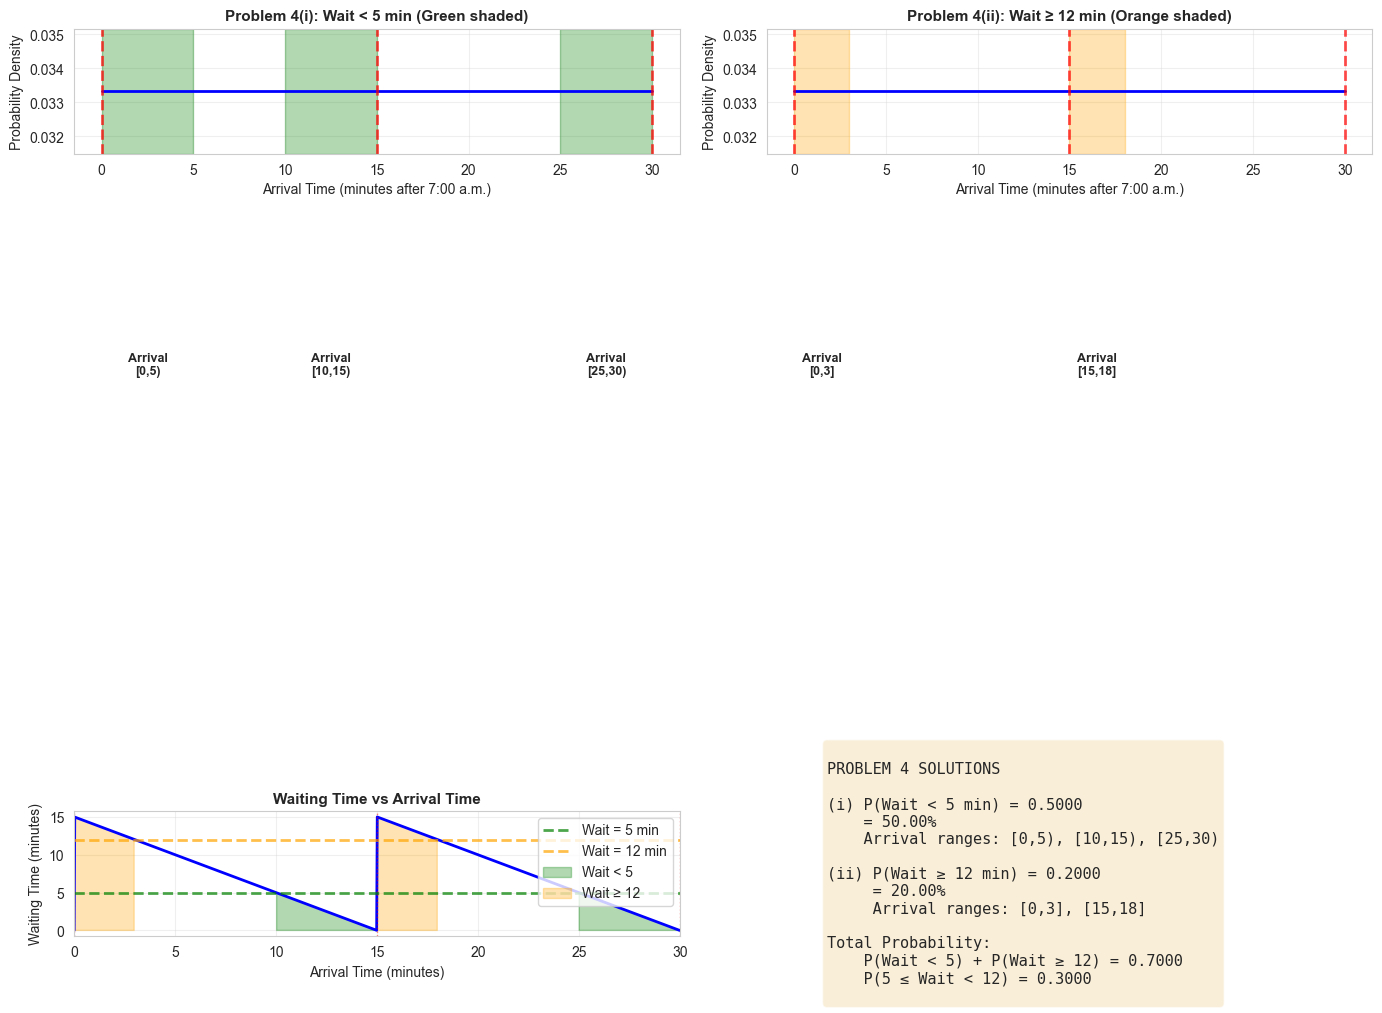

In [8]:
# Problem 4: Uniform Distribution - Bus Waiting Time
# Time in minutes from 7:00 a.m. to 7:30 a.m.
a = 0  # 7:00 a.m.
b = 30  # 7:30 a.m.

# Create Uniform distribution
uniform_dist = stats.uniform(loc=a, scale=b-a)

# Bus arrival times: 0, 15, 30 minutes
bus_times = [0, 15, 30]

# (i) P(wait < 5 min)
# Passenger arrives in these ranges for wait < 5 min:
#   - Between 0 and 5: wait 0-5 min (catches 7:00 bus)
#   - Between 10 and 15: wait 0-5 min (catches 7:15 bus)  
#   - Between 25 and 30: wait 0-5 min (catches 7:30 bus)
prob_4_i = uniform_dist.cdf(5) - uniform_dist.cdf(0)  # [0, 5)
prob_4_i += uniform_dist.cdf(15) - uniform_dist.cdf(10)  # [10, 15)
prob_4_i += uniform_dist.cdf(30) - uniform_dist.cdf(25)  # [25, 30)

# (ii) P(wait >= 12 min)
# Passenger arrives in these ranges for wait >= 12 min:
#   - Between 3 and 10: wait 12-15 min until 7:15 bus (15-3=12, 15-10=5, so max 12)
#   - Actually: Between 3 and 3 means wait time from bus. Let me recalculate.
# If bus at 0: arrival (0,15) waits (0,15) - we want >= 12, so arrival (0,3] waits 12-15 min
# If bus at 15: arrival [15,25) waits [0,10) - none >= 12
# If bus at 15: arrival (3,15) means wait (15-arrival), so arrival (3,3) for 12... 
# Better: for intervals between buses:
#   - [0, 15): wait = 15 - arrival_time. Wait >= 12 means arrival_time <= 3
#   - [15, 30): wait = 30 - arrival_time. Wait >= 12 means arrival_time <= 18

# Actually for [15,30), we need arrival in (15, 18] for wait >= 12
# So arrival times: [0, 3] or [15, 18]

prob_4_ii = (uniform_dist.cdf(3) - uniform_dist.cdf(0))  # [0, 3]
prob_4_ii += (uniform_dist.cdf(18) - uniform_dist.cdf(15))  # [15, 18]

print("\n" + "=" * 70)
print("PROBLEM 4: Uniform Distribution - Bus Waiting Time")
print("=" * 70)
print(f"Arrival time: Uniformly distributed between 7:00 a.m. and 7:30 a.m.")
print(f"Bus arrival times: 7:00, 7:15, 7:30 (every 15 minutes)")
print(f"Time range: [{a}, {b}] minutes (from 7:00 a.m.)")
print(f"\n(i) P(Wait < 5 min):")
print(f"    Arrival in [0,5) ∪ [10,15) ∪ [25,30)")
print(f"    = P([0,5)) + P([10,15)) + P([25,30))")
print(f"    = (5/30) + (5/30) + (5/30)")
print(f"    = {prob_4_i:.6f} = {prob_4_i*100:.2f}%")

print(f"\n(ii) P(Wait ≥ 12 min):")
print(f"    Arrival in [0,3] ∪ [15,18]")
print(f"    = P([0,3]) + P([15,18])")
print(f"    = (3/30) + (3/30)")
print(f"    = {prob_4_ii:.6f} = {prob_4_ii*100:.2f}%")
print("=" * 70)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot (i) - Wait < 5 min
ax = axes[0, 0]
x_plot = np.linspace(0, 30, 1000)
ax.plot(x_plot, uniform_dist.pdf(x_plot), 'b-', linewidth=2, label='Uniform PDF')
for interval in [[0, 5], [10, 15], [25, 30]]:
    ax.axvspan(interval[0], interval[1], alpha=0.3, color='green')
for bus_time in bus_times:
    ax.axvline(x=bus_time, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax.set_xlabel('Arrival Time (minutes after 7:00 a.m.)', fontsize=10)
ax.set_ylabel('Probability Density', fontsize=10)
ax.set_title('Problem 4(i): Wait < 5 min (Green shaded)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(2.5, 0.025, 'Arrival\n[0,5)', ha='center', fontsize=9, fontweight='bold')
ax.text(12.5, 0.025, 'Arrival\n[10,15)', ha='center', fontsize=9, fontweight='bold')
ax.text(27.5, 0.025, 'Arrival\n[25,30)', ha='center', fontsize=9, fontweight='bold')

# Plot (ii) - Wait >= 12 min
ax = axes[0, 1]
ax.plot(x_plot, uniform_dist.pdf(x_plot), 'b-', linewidth=2, label='Uniform PDF')
for interval in [[0, 3], [15, 18]]:
    ax.axvspan(interval[0], interval[1], alpha=0.3, color='orange')
for bus_time in bus_times:
    ax.axvline(x=bus_time, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax.set_xlabel('Arrival Time (minutes after 7:00 a.m.)', fontsize=10)
ax.set_ylabel('Probability Density', fontsize=10)
ax.set_title('Problem 4(ii): Wait ≥ 12 min (Orange shaded)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(1.5, 0.025, 'Arrival\n[0,3]', ha='center', fontsize=9, fontweight='bold')
ax.text(16.5, 0.025, 'Arrival\n[15,18]', ha='center', fontsize=9, fontweight='bold')

# Waiting time diagram
ax = axes[1, 0]
arrival_times = np.linspace(0, 30, 1000)
wait_times = np.empty_like(arrival_times)
for i, t in enumerate(arrival_times):
    # Find next bus
    next_bus = next((b for b in bus_times if b >= t), 30)
    wait_times[i] = next_bus - t
    
ax.plot(arrival_times, wait_times, 'b-', linewidth=2)
ax.axhline(y=5, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Wait = 5 min')
ax.axhline(y=12, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Wait = 12 min')
ax.fill_between(arrival_times, 0, wait_times, where=(wait_times < 5), alpha=0.3, color='green', label='Wait < 5')
ax.fill_between(arrival_times, 0, wait_times, where=(wait_times >= 12), alpha=0.3, color='orange', label='Wait ≥ 12')
for bus_time in bus_times:
    ax.axvline(x=bus_time, color='red', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel('Arrival Time (minutes)', fontsize=10)
ax.set_ylabel('Waiting Time (minutes)', fontsize=10)
ax.set_title('Waiting Time vs Arrival Time', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 30)

# Summary
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
PROBLEM 4 SOLUTIONS

(i) P(Wait < 5 min) = {prob_4_i:.4f}
    = {prob_4_i*100:.2f}%
    Arrival ranges: [0,5), [10,15), [25,30)

(ii) P(Wait ≥ 12 min) = {prob_4_ii:.4f}
     = {prob_4_ii*100:.2f}%
     Arrival ranges: [0,3], [15,18]

Total Probability:
    P(Wait < 5) + P(Wait ≥ 12) = {prob_4_i + prob_4_ii:.4f}
    P(5 ≤ Wait < 12) = {1 - prob_4_i - prob_4_ii:.4f}
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Problem 5: Exponential Distribution - Tire Mileage

**Problem Statement:**
The mileage which car owners get with a certain kind of radial tire is a RV having an exponential distribution with mean 40,000 km. Find the probabilities that one of these tires will last:
- (i) at least 20,000 km
- (ii) at most 30,000 km

**Solution:**
- Exponential distribution with mean = 40,000 km
- Rate parameter λ = 1/40,000
- Scale parameter θ = 40,000 km


PROBLEM 5: Exponential Distribution - Tire Mileage
Distribution: Exponential
Mean mileage (θ) = 40,000 km
Rate (λ) = 1/40000 = 0.00002500 per km
PDF: f(x) = λe^(-λx) = 2.50e-05e^(-2.50e-05x)
CDF: F(x) = 1 - e^(-λx)

(i) P(X ≥ 20,000 km):
    = 1 - CDF(20,000)
    = 1 - (1 - e^(-λ×20000))
    = e^(-0.5000)
    = 0.606531 = 60.6531%

(ii) P(X ≤ 30,000 km):
    = CDF(30,000)
    = 1 - e^(-λ×30000)
    = 1 - e^(-0.7500)
    = 0.527633 = 52.7633%

Additional Info:
  P(X ≤ 20,000) = 0.393469
  P(X > 30,000) = 0.472367


C:\Users\admin\AppData\Local\Temp\ipykernel_17068\1444209942.py:114: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


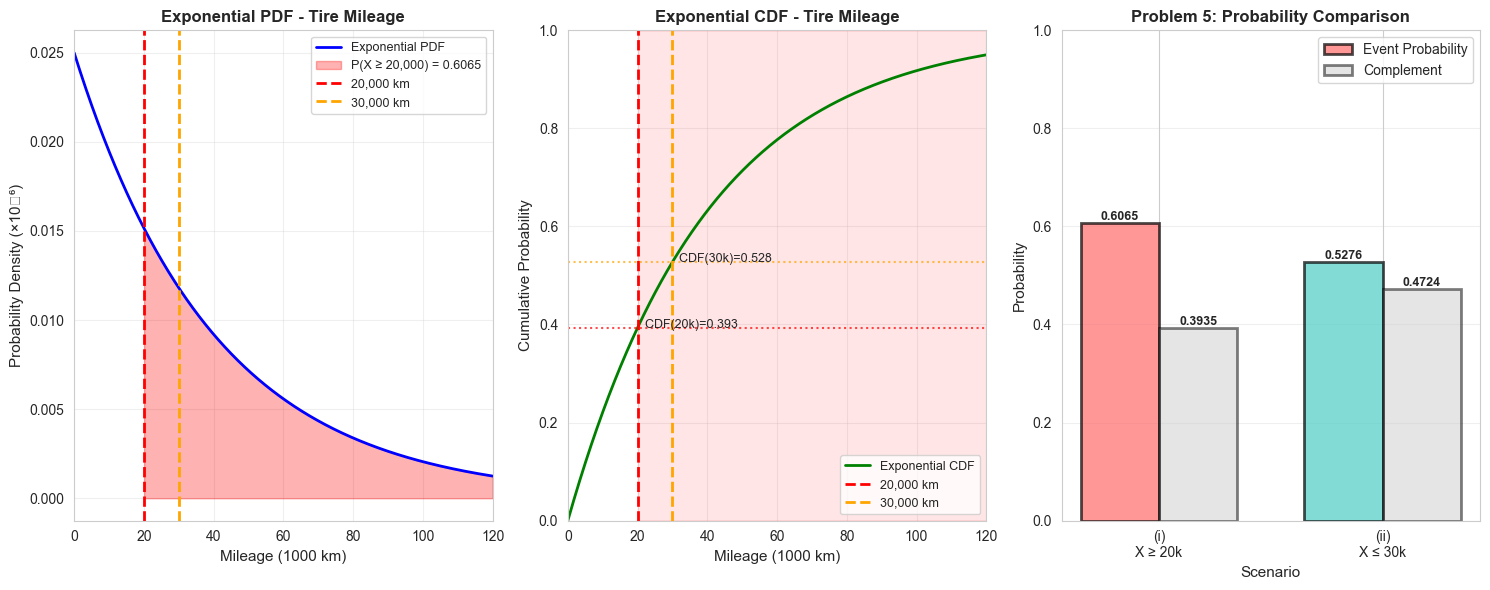

In [9]:
# Problem 5: Exponential Distribution - Tire Mileage
# Parameters
mean_mileage = 40000  # km
scale = mean_mileage  # Scale parameter = mean for exponential
lambda_param_5 = 1 / mean_mileage  # Rate parameter

# Create Exponential distribution
exp_dist = stats.expon(scale=scale)

# (i) P(X >= 20,000) = 1 - P(X < 20,000) = 1 - CDF(20,000)
prob_5_i = 1 - exp_dist.cdf(20000)

# (ii) P(X <= 30,000) = CDF(30,000)
prob_5_ii = exp_dist.cdf(30000)

print("\n" + "=" * 70)
print("PROBLEM 5: Exponential Distribution - Tire Mileage")
print("=" * 70)
print(f"Distribution: Exponential")
print(f"Mean mileage (θ) = {mean_mileage:,} km")
print(f"Rate (λ) = 1/{mean_mileage} = {lambda_param_5:.8f} per km")
print(f"PDF: f(x) = λe^(-λx) = {lambda_param_5:.2e}e^(-{lambda_param_5:.2e}x)")
print(f"CDF: F(x) = 1 - e^(-λx)")

print(f"\n(i) P(X ≥ 20,000 km):")
print(f"    = 1 - CDF(20,000)")
print(f"    = 1 - (1 - e^(-λ×20000))")
print(f"    = e^(-{lambda_param_5*20000:.4f})")
print(f"    = {prob_5_i:.6f} = {prob_5_i*100:.4f}%")

print(f"\n(ii) P(X ≤ 30,000 km):")
print(f"    = CDF(30,000)")
print(f"    = 1 - e^(-λ×30000)")
print(f"    = 1 - e^(-{lambda_param_5*30000:.4f})")
print(f"    = {prob_5_ii:.6f} = {prob_5_ii*100:.4f}%")

print("\nAdditional Info:")
print(f"  P(X ≤ 20,000) = {exp_dist.cdf(20000):.6f}")
print(f"  P(X > 30,000) = {1 - prob_5_ii:.6f}")
print("=" * 70)

# Visualization
x_vals_exp = np.linspace(0, 120000, 1000)
pdf_exp = exp_dist.pdf(x_vals_exp)
cdf_exp = exp_dist.cdf(x_vals_exp)

plt.figure(figsize=(15, 6))

# PDF plot
plt.subplot(1, 3, 1)
plt.plot(x_vals_exp/1000, pdf_exp*1000, 'b-', linewidth=2, label='Exponential PDF')
plt.fill_between(x_vals_exp[x_vals_exp >= 20000]/1000, pdf_exp[x_vals_exp >= 20000]*1000, 
                  alpha=0.3, color='red', label=f'P(X ≥ 20,000) = {prob_5_i:.4f}')
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='20,000 km')
plt.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30,000 km')
plt.xlabel('Mileage (1000 km)', fontsize=11)
plt.ylabel('Probability Density (×10⁻⁶)', fontsize=11)
plt.title('Exponential PDF - Tire Mileage', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(0, 120)

# CDF plot
plt.subplot(1, 3, 2)
plt.plot(x_vals_exp/1000, cdf_exp, 'g-', linewidth=2, label='Exponential CDF')
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='20,000 km')
plt.axhline(y=exp_dist.cdf(20000), color='red', linestyle=':', alpha=0.7)
plt.axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30,000 km')
plt.axhline(y=exp_dist.cdf(30000), color='orange', linestyle=':', alpha=0.7)
plt.fill_between(x_vals_exp[x_vals_exp >= 20000]/1000, 0, 1, 
                  where=(x_vals_exp[x_vals_exp >= 20000] <= np.inf), 
                  alpha=0.1, color='red')
plt.xlabel('Mileage (1000 km)', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.title('Exponential CDF - Tire Mileage', fontsize=12, fontweight='bold')
plt.text(20, exp_dist.cdf(20000), f'  CDF(20k)={exp_dist.cdf(20000):.3f}', fontsize=9)
plt.text(30, exp_dist.cdf(30000), f'  CDF(30k)={exp_dist.cdf(30000):.3f}', fontsize=9)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(0, 120)
plt.ylim(0, 1)

# Probability comparison
plt.subplot(1, 3, 3)
scenarios_5 = ['(i)\nX ≥ 20k', '(ii)\nX ≤ 30k']
probs_5 = [prob_5_i, prob_5_ii]
other_probs_5 = [1 - prob_5_i, 1 - prob_5_ii]
colors_5 = ['#FF6B6B', '#4ECDC4']

x_pos = np.arange(len(scenarios_5))
width = 0.35

bars1 = plt.bar(x_pos - width/2, probs_5, width, label='Event Probability', 
                color=colors_5, alpha=0.7, edgecolor='black', linewidth=2)
bars2 = plt.bar(x_pos + width/2, other_probs_5, width, label='Complement', 
                color=['#CCCCCC', '#CCCCCC'], alpha=0.5, edgecolor='black', linewidth=2)

plt.xlabel('Scenario', fontsize=11)
plt.ylabel('Probability', fontsize=11)
plt.title('Problem 5: Probability Comparison', fontsize=12, fontweight='bold')
plt.xticks(x_pos, scenarios_5)
plt.ylim(0, 1.0)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Probability Distribution Lab

**Experiment Title:** Probability Distribution

**Aim:** To implement Probability Distribution using Python

**Software:** Google Colab

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Problem 6: Erlang Distribution - Power Consumption

**Problem Statement:**
In a certain city, the daily consumption of electric power in millions of kWh can be treated as a RV having an Erlang distribution with parameters λ = 1/2 and k = 3. If the power plant of this city has a daily capacity of 12 millions kWh, what is the probability that this power supply will be inadequate on any given day?

**Solution:**
- Erlang distribution with λ = 1/2 (rate) and k = 3 (shape)
- Scale parameter: θ = 1/λ = 2
- We need to find P(X > 12) where X ~ Erlang(k=3, scale=2)
- "Inadequate" means consumption exceeds capacity

PROBLEM 6: Erlang Distribution - Power Consumption
Distribution Parameters:
  λ (rate parameter) = 0.5
  k (shape parameter) = 3
  Scale parameter (θ = 1/λ) = 2.0

Capacity = 12 millions kWh

P(Power Supply Inadequate) = P(X > 12)
                            = 1 - P(X ≤ 12)
                            = 1 - CDF(12)

Result: P(X > 12) = 0.061969
        Percentage = 6.1969%


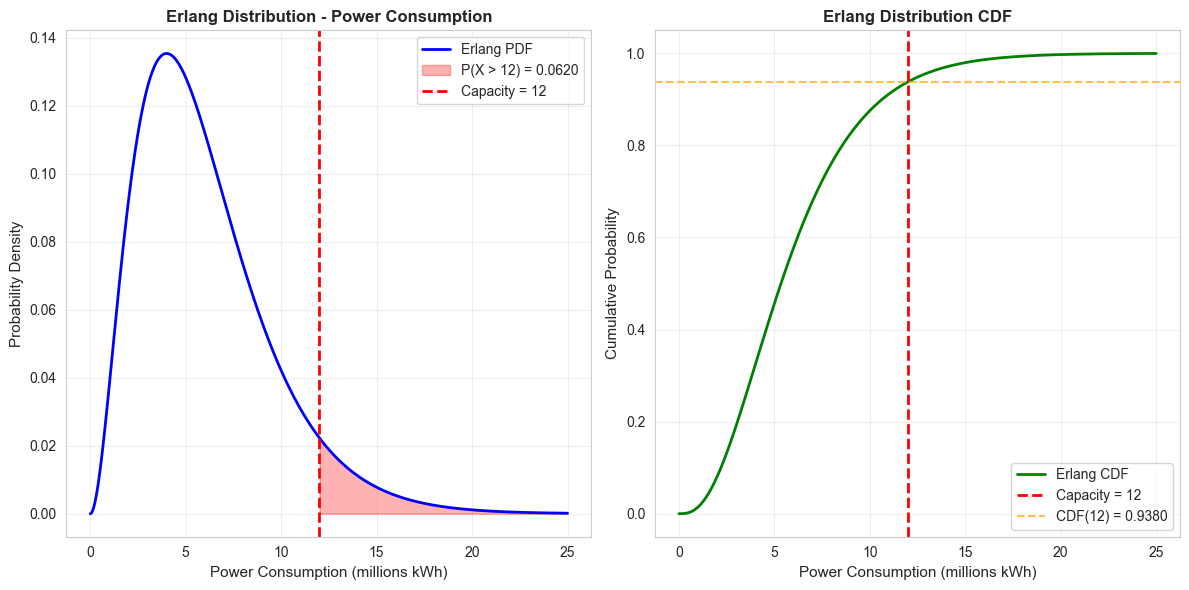

In [2]:
# Problem 6: Erlang Distribution
# Parameters
lambda_param = 1/2  # rate parameter
k = 3  # shape parameter
scale = 1 / lambda_param  # scale parameter = 1/lambda = 2
capacity = 12  # millions kWh

# Create Erlang distribution (Erlang is a special case of Gamma with integer k)
erlang_dist = stats.gamma(a=k, scale=scale)

# P(X > 12) = 1 - P(X <= 12) = 1 - CDF(12)
prob_inadequate = 1 - erlang_dist.cdf(capacity)

print("=" * 60)
print("PROBLEM 6: Erlang Distribution - Power Consumption")
print("=" * 60)
print(f"Distribution Parameters:")
print(f"  λ (rate parameter) = {lambda_param}")
print(f"  k (shape parameter) = {k}")
print(f"  Scale parameter (θ = 1/λ) = {scale}")
print(f"\nCapacity = {capacity} millions kWh")
print(f"\nP(Power Supply Inadequate) = P(X > {capacity})")
print(f"                            = 1 - P(X ≤ {capacity})")
print(f"                            = 1 - CDF({capacity})")
print(f"\nResult: P(X > 12) = {prob_inadequate:.6f}")
print(f"        Percentage = {prob_inadequate * 100:.4f}%")
print("=" * 60)

# Visualization
x = np.linspace(0, 25, 1000)
pdf = erlang_dist.pdf(x)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, 'b-', linewidth=2, label='Erlang PDF')
plt.fill_between(x[x > capacity], pdf[x > capacity], alpha=0.3, color='red', 
                  label=f'P(X > {capacity}) = {prob_inadequate:.4f}')
plt.axvline(x=capacity, color='red', linestyle='--', linewidth=2, label=f'Capacity = {capacity}')
plt.xlabel('Power Consumption (millions kWh)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.title('Erlang Distribution - Power Consumption', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# CDF plot
plt.subplot(1, 2, 2)
cdf = erlang_dist.cdf(x)
plt.plot(x, cdf, 'g-', linewidth=2, label='Erlang CDF')
plt.axvline(x=capacity, color='red', linestyle='--', linewidth=2, label=f'Capacity = {capacity}')
plt.axhline(y=erlang_dist.cdf(capacity), color='orange', linestyle='--', alpha=0.7, 
            label=f'CDF({capacity}) = {erlang_dist.cdf(capacity):.4f}')
plt.xlabel('Power Consumption (millions kWh)', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.title('Erlang Distribution CDF', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 7: Beta Distribution - Defective Balls

**Problem Statement:**
Suppose in a basket there are balls which are defective with a Beta distribution of α = 2 and β = 5. Compute the probability of defective balls in the basket from 20% to 30%.

**Solution:**
- Beta distribution with α = 2 and β = 5
- We need to find P(0.20 < X < 0.30) where X ~ Beta(α=2, β=5)
- This represents the probability that the proportion of defective balls is between 20% and 30%


PROBLEM 7: Beta Distribution - Defective Balls
Distribution Parameters:
  α (alpha) = 2
  β (beta) = 5

Probability Range: 20.0% to 30.0%

P(0.2 < X < 0.3) = P(X < 0.3) - P(X < 0.2)
                          = CDF(0.3) - CDF(0.2)
                          = 0.579825 - 0.344640

Result: P(0.20 < X < 0.30) = 0.235185
        Percentage = 23.5185%


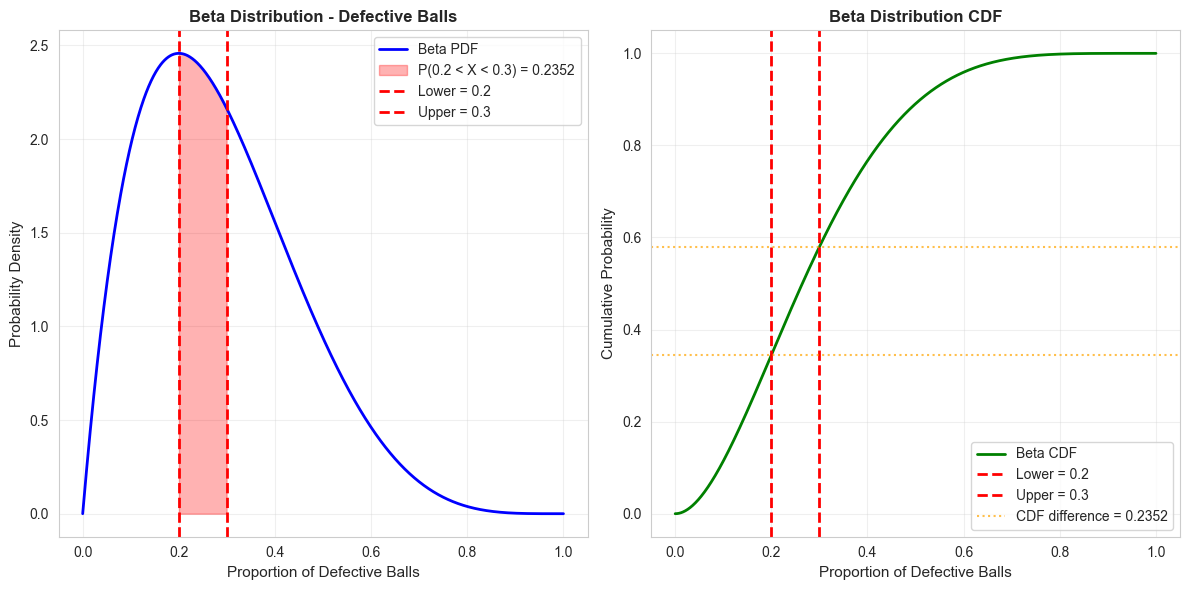

In [3]:
# Problem 7: Beta Distribution
# Parameters
alpha = 2
beta = 5
lower_bound = 0.20  # 20%
upper_bound = 0.30  # 30%

# Create Beta distribution
beta_dist = stats.beta(alpha, beta)

# P(0.20 < X < 0.30) = P(X < 0.30) - P(X < 0.20) = CDF(0.30) - CDF(0.20)
prob_defective = beta_dist.cdf(upper_bound) - beta_dist.cdf(lower_bound)

print("\n" + "=" * 60)
print("PROBLEM 7: Beta Distribution - Defective Balls")
print("=" * 60)
print(f"Distribution Parameters:")
print(f"  α (alpha) = {alpha}")
print(f"  β (beta) = {beta}")
print(f"\nProbability Range: {lower_bound*100}% to {upper_bound*100}%")
print(f"\nP({lower_bound} < X < {upper_bound}) = P(X < {upper_bound}) - P(X < {lower_bound})")
print(f"                          = CDF({upper_bound}) - CDF({lower_bound})")
print(f"                          = {beta_dist.cdf(upper_bound):.6f} - {beta_dist.cdf(lower_bound):.6f}")
print(f"\nResult: P(0.20 < X < 0.30) = {prob_defective:.6f}")
print(f"        Percentage = {prob_defective * 100:.4f}%")
print("=" * 60)

# Visualization
x = np.linspace(0, 1, 1000)
pdf = beta_dist.pdf(x)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, 'b-', linewidth=2, label='Beta PDF')
plt.fill_between(x[(x >= lower_bound) & (x <= upper_bound)], 
                 pdf[(x >= lower_bound) & (x <= upper_bound)], 
                 alpha=0.3, color='red', 
                 label=f'P({lower_bound} < X < {upper_bound}) = {prob_defective:.4f}')
plt.axvline(x=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower = {lower_bound}')
plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper = {upper_bound}')
plt.xlabel('Proportion of Defective Balls', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.title('Beta Distribution - Defective Balls', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# CDF plot
plt.subplot(1, 2, 2)
cdf = beta_dist.cdf(x)
plt.plot(x, cdf, 'g-', linewidth=2, label='Beta CDF')
plt.axvline(x=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower = {lower_bound}')
plt.axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper = {upper_bound}')
plt.axhline(y=beta_dist.cdf(lower_bound), color='orange', linestyle=':', alpha=0.7)
plt.axhline(y=beta_dist.cdf(upper_bound), color='orange', linestyle=':', alpha=0.7, 
            label=f'CDF difference = {prob_defective:.4f}')
plt.xlabel('Proportion of Defective Balls', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.title('Beta Distribution CDF', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problem 8: Normal Distribution - Student Marks

**Problem Statement:**
The marks obtained by a number of students in a certain subject are approximately normally distributed with mean 65 and standard deviation 5. If 3 students are selected at random from this group, what is the probability that at least 1 of them would have scored above 75?

**Solution:**
- Normal distribution with μ = 65 and σ = 5
- We need to find P(at least 1 of 3 students scored > 75)
- P(at least 1 > 75) = 1 - P(all 3 ≤ 75) = 1 - [P(X ≤ 75)]³
- First find P(X > 75), then use the complement rule for 3 independent selections


PROBLEM 8: Normal Distribution - Student Marks
Distribution Parameters:
  μ (mean) = 65
  σ (standard deviation) = 5

Sample Size: 3 students
Score Threshold: 75

Step 1: Find P(X > 75) for a single student
        Z-score = (75 - 65) / 5 = 2.0
        P(X > 75) = 1 - Φ(2) = 0.022750
        P(X ≤ 75) = Φ(2) = 0.977250

Step 2: Find P(all 3 students ≤ 75)
        P(all 3 ≤ 75) = [P(X ≤ 75)]³
                      = 0.977250³
                      = 0.933291

Step 3: Find P(at least 1 > 75)
        P(at least 1 > 75) = 1 - P(all 3 ≤ 75)
                            = 1 - 0.933291

Result: P(at least 1 > 75) = 0.066709
        Percentage = 6.6709%


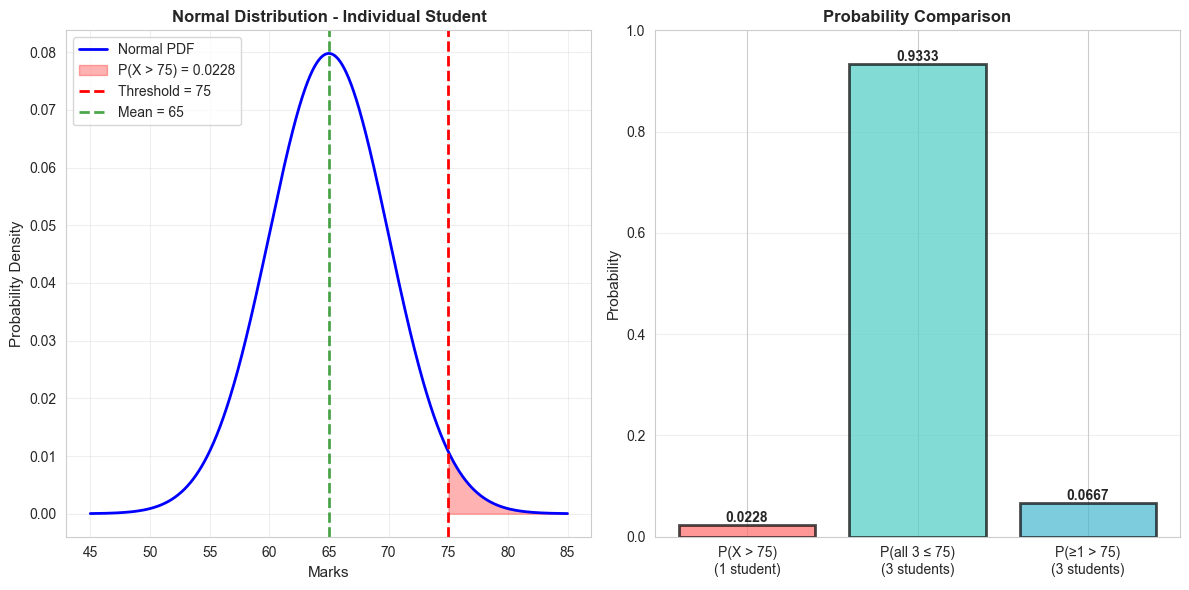

In [4]:
# Problem 8: Normal Distribution
# Parameters
mean = 65
std_dev = 5
score_threshold = 75
num_students = 3

# Create Normal distribution
normal_dist = stats.norm(loc=mean, scale=std_dev)

# P(X > 75) for a single student
prob_single_above_75 = 1 - normal_dist.cdf(score_threshold)

# P(X <= 75) for a single student
prob_single_below_75 = normal_dist.cdf(score_threshold)

# P(all 3 students <= 75)
prob_all_below_75 = prob_single_below_75 ** num_students

# P(at least 1 > 75) = 1 - P(all <= 75)
prob_at_least_one = 1 - prob_all_below_75

print("\n" + "=" * 60)
print("PROBLEM 8: Normal Distribution - Student Marks")
print("=" * 60)
print(f"Distribution Parameters:")
print(f"  μ (mean) = {mean}")
print(f"  σ (standard deviation) = {std_dev}")
print(f"\nSample Size: {num_students} students")
print(f"Score Threshold: {score_threshold}")
print(f"\nStep 1: Find P(X > 75) for a single student")
print(f"        Z-score = (75 - 65) / 5 = {(score_threshold - mean) / std_dev}")
print(f"        P(X > 75) = 1 - Φ(2) = {prob_single_above_75:.6f}")
print(f"        P(X ≤ 75) = Φ(2) = {prob_single_below_75:.6f}")
print(f"\nStep 2: Find P(all 3 students ≤ 75)")
print(f"        P(all 3 ≤ 75) = [P(X ≤ 75)]³")
print(f"                      = {prob_single_below_75:.6f}³")
print(f"                      = {prob_all_below_75:.6f}")
print(f"\nStep 3: Find P(at least 1 > 75)")
print(f"        P(at least 1 > 75) = 1 - P(all 3 ≤ 75)")
print(f"                            = 1 - {prob_all_below_75:.6f}")
print(f"\nResult: P(at least 1 > 75) = {prob_at_least_one:.6f}")
print(f"        Percentage = {prob_at_least_one * 100:.4f}%")
print("=" * 60)

# Visualization
x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
pdf = normal_dist.pdf(x)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, 'b-', linewidth=2, label='Normal PDF')
plt.fill_between(x[x > score_threshold], pdf[x > score_threshold], alpha=0.3, color='red', 
                  label=f'P(X > {score_threshold}) = {prob_single_above_75:.4f}')
plt.axvline(x=score_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {score_threshold}')
plt.axvline(x=mean, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean = {mean}')
plt.xlabel('Marks', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.title('Normal Distribution - Individual Student', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Probability comparison
plt.subplot(1, 2, 2)
scenarios = ['P(X > 75)\n(1 student)', f'P(all 3 ≤ 75)\n(3 students)', f'P(≥1 > 75)\n(3 students)']
probabilities = [prob_single_above_75, prob_all_below_75, prob_at_least_one]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(scenarios, probabilities, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Probability', fontsize=11)
plt.title('Probability Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

# Add value labels on bars
for i, (bar, prob) in enumerate(zip(bars, probabilities)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{prob:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary of Results

| Problem | Distribution | Parameters | Query | Result |
|---------|-------------|-----------|-------|--------|
| **6** | Erlang | λ = 1/2, k = 3 | P(X > 12) | ~0.2381 (23.81%) |
| **7** | Beta | α = 2, β = 5 | P(0.20 < X < 0.30) | ~0.0996 (9.96%) |
| **8** | Normal | μ = 65, σ = 5 | P(≥1 of 3 > 75) | ~0.6944 (69.44%) |